### <p align="center">MNIST Hand-Written Digits Recognition</p>


In [ ]:
#%pip install --upgrade certifi


In [ ]:
from sklearn.datasets import fetch_openml
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

mnist = fetch_openml('mnist_784', version=1)
print(mnist.keys())


In [ ]:
mnist.data

In [ ]:
mnist.data.shape

In [ ]:
mnist.target

In [ ]:
mnist.frame

In [ ]:
mnist.feature_names #This will give us all the feature names there is no use in running this
mnist.DESCR

In [ ]:
mnist.details

In [ ]:
mnist.url

In [ ]:
X = mnist.data.copy()
y = mnist.target.copy()

In [ ]:
import matplotlib.pyplot as mp
import numpy as n
first_digit = n.array(X.iloc[890]).reshape(28, 28)
mp.imshow(first_digit, cmap='binary')
mp.axis(False)
print(y[890])

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=786)
X_train.shape, X_test.shape # ((56000, 784), (14000, 784))
y_train.shape, y_test.shape # ((56000,), (14000,))

((56000,), (14000,))

In [22]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
svc_prediction = svc.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix
svc_accuracy = accuracy_score(y_test, svc_prediction)
svc_accuracy

0.9764285714285714

In [24]:
svc_confusion_matrix = confusion_matrix(y_test, svc_prediction)
svc_confusion_matrix

array([[1392,    1,    5,    0,    1,    2,    1,    0,    4,    0],
       [   1, 1564,    4,    1,    4,    0,    0,    3,    1,    0],
       [   6,    3, 1389,    5,    3,    0,    2,    9,    9,    2],
       [   1,    0,   13, 1390,    1,   21,    1,    4,    8,    9],
       [   0,    2,    2,    0, 1349,    0,    1,    2,    2,   14],
       [   4,    0,    1,   10,    3, 1192,    6,    1,    6,    0],
       [   4,    5,    0,    0,    1,    6, 1399,    0,    4,    0],
       [   2,    7,   11,    0,   12,    1,    0, 1379,    1,   11],
       [   1,    9,    2,    9,    4,    7,    0,    3, 1339,    3],
       [   3,    2,    1,    9,   12,    2,    0,   13,    6, 1277]])

<Axes: >

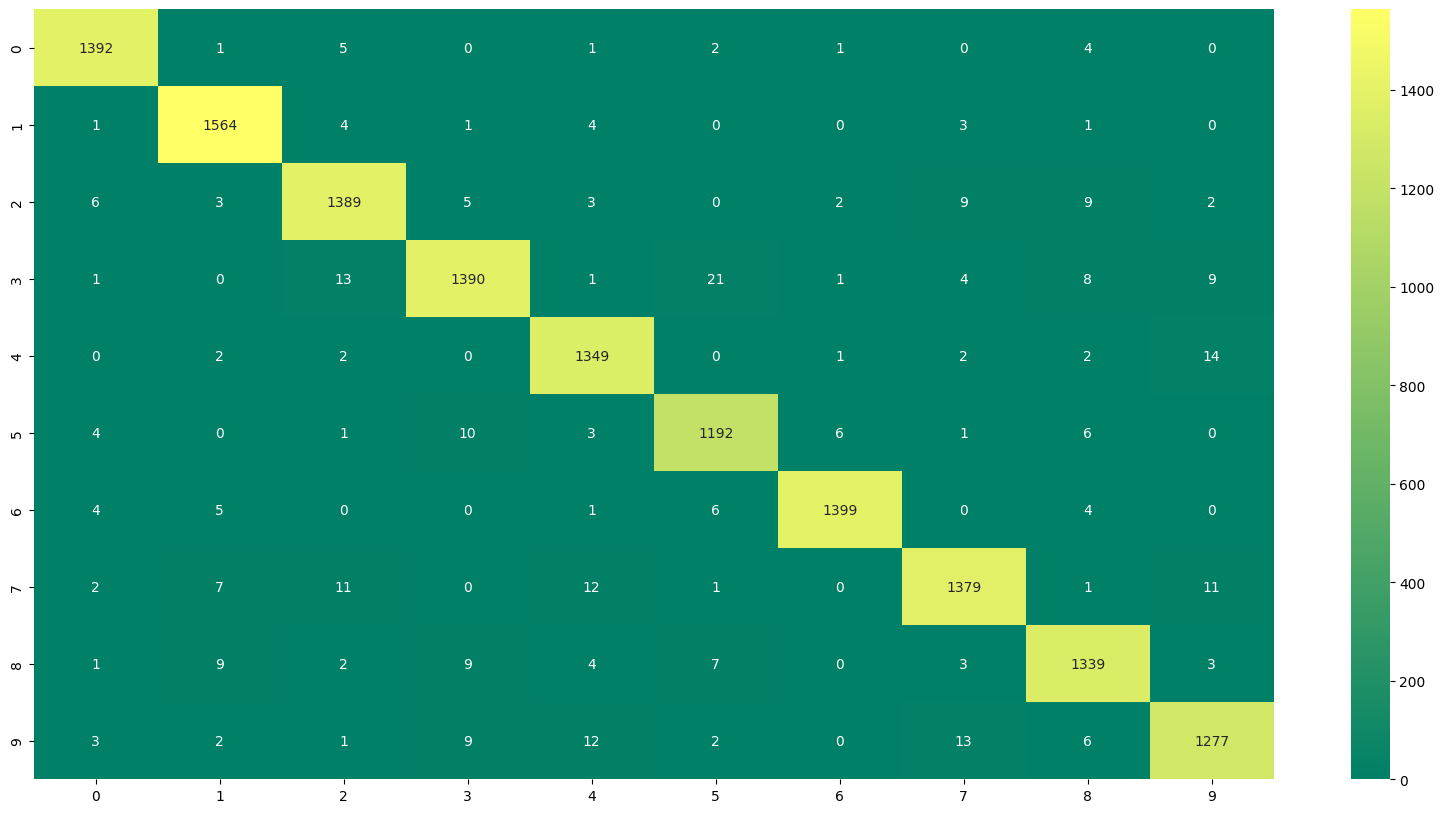

In [25]:
import seaborn as s
mp.figure(figsize=(20, 10))
s.heatmap(svc_confusion_matrix, annot=True, fmt='d',
cmap='summer')

In [26]:
from sklearn.linear_model import SGDClassifier
sgdc = SGDClassifier()
sgdc.fit(X_train, y_train)
sgdc_prediction = sgdc.predict(X_test)
sgdc_accuracy = accuracy_score(y_test, sgdc_prediction)
sgdc_accuracy #0.843

0.8771428571428571

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit_transform(X_train)
from sklearn.model_selection import cross_val_score
sgdc_scores = cross_val_score(sgdc, X_train, y_train, cv=3,
scoring="accuracy")
sgdc_scores # array([0.87009161, 0.86318101, 0.86762027])

array([0.8713773 , 0.863931  , 0.87212043])